In [1]:
import pickle 

filepath = "../data/pre_process/graph_construction/graph.pkl"
with open(filepath, 'rb') as f:
    graph = pickle.load(f)
graph

In [2]:
label_dict = {}
for u,v, edge in graph.edges(data=True):
    if edge['label'] not in label_dict:
        label_dict[edge['label']] = []

    label_node = graph.nodes[u]['label']
    if not label_node:
        label_node = graph.nodes[v]['label']
    label_dict[edge['label']].append(label_node)


In [3]:
import re

label_dict_cleaned = {}
for label, value in label_dict.items():
    new_label = re.sub(r'\[\d+\]', '', label)
    label_dict_cleaned[new_label] = list(set(value))
len(label_dict_cleaned)

435

In [4]:
import json 

filepath = "../validated_labels_2.json"
with open(filepath, 'r') as f:
    validated_labels = json.load(f)
len(validated_labels)

49

In [5]:
validated_mini_labels = []
for label in validated_labels:
    mini_labels = label.split('.')
    validated_mini_labels.extend(mini_labels)
validated_mini_labels = list(set(validated_mini_labels))

In [6]:
import fasttext

model = fasttext.load_model("../cc.en.300.bin")
embeddings = {w: model.get_word_vector(w) for w in validated_mini_labels}

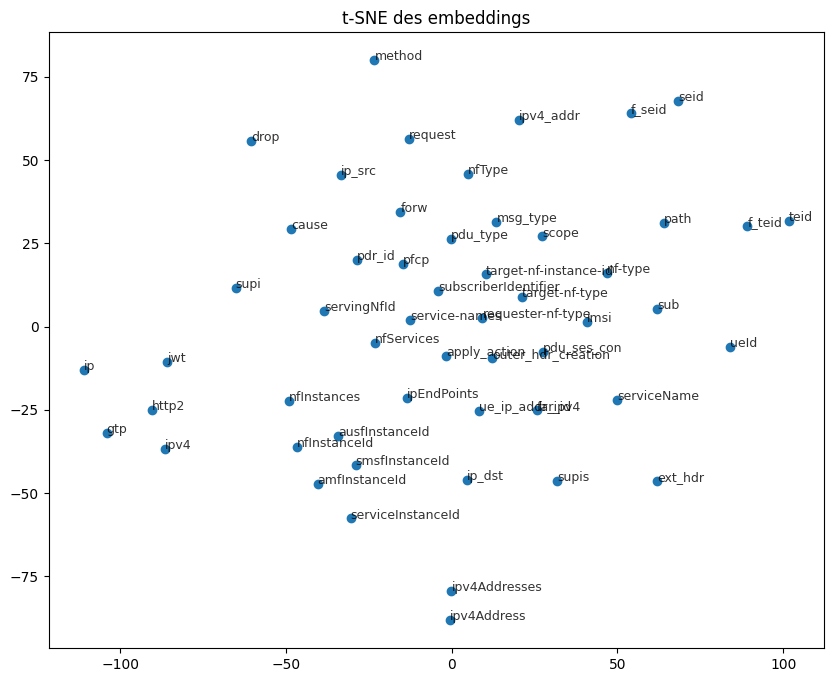

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

labels = list(embeddings.keys())
X = np.vstack([embeddings[l] for l in labels])

tsne = TSNE(
    n_components=2,
    perplexity=10,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_2d = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1])

for i, label in enumerate(labels):
    plt.text(
        X_2d[i, 0],
        X_2d[i, 1],
        label,
        fontsize=9,
        alpha=0.8
    )

plt.title("t-SNE des embeddings")
plt.show()

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

X = X / np.linalg.norm(X, axis=1, keepdims=True)
S = cosine_similarity(X)  # matrice NxN

def nearest_neighbors(label, topk=5):
    idx = labels.index(label)
    sims = S[idx]

    neighbors = [
        (labels[i], f"{sims[i]:.3f}")
        for i in np.argsort(-sims)
        if labels[i] != label
    ]

    return neighbors[:topk]

for label in labels:
    print(f"Neighbors for {label}:")
    for n, k, in nearest_neighbors(label, topk=5):
        print(f" - {n} (sim: {k})")

Neighbors for target-nf-type:
 - nf-type (sim: 0.750)
 - requester-nf-type (sim: 0.721)
 - target-nf-instance-id (sim: 0.715)
 - outer_hdr_creation (sim: 0.489)
 - subscriberIdentifier (sim: 0.460)
Neighbors for outer_hdr_creation:
 - nf-type (sim: 0.565)
 - requester-nf-type (sim: 0.536)
 - ue_ip_addr_ipv4 (sim: 0.491)
 - target-nf-type (sim: 0.489)
 - apply_action (sim: 0.486)
Neighbors for f_teid:
 - teid (sim: 0.701)
 - ausfInstanceId (sim: 0.400)
 - smsfInstanceId (sim: 0.383)
 - nfInstanceId (sim: 0.329)
 - serviceInstanceId (sim: 0.301)
Neighbors for amfInstanceId:
 - smsfInstanceId (sim: 0.837)
 - ausfInstanceId (sim: 0.824)
 - nfInstanceId (sim: 0.815)
 - serviceInstanceId (sim: 0.663)
 - nfInstances (sim: 0.412)
Neighbors for sub:
 - gtp (sim: 0.220)
 - nf-type (sim: 0.218)
 - target-nf-type (sim: 0.202)
 - ipv4 (sim: 0.201)
 - serviceName (sim: 0.198)
Neighbors for jwt:
 - http2 (sim: 0.525)
 - gtp (sim: 0.420)
 - supi (sim: 0.420)
 - ip (sim: 0.376)
 - forw (sim: 0.331)
Nei